In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder, StandardScaler


### Environment Setup and Library Imports
In this cell, we import all the necessary libraries:
* **numpy & pandas**: For data manipulation, numerical operations, and DataFrame handling.
* **matplotlib & seaborn**: For visualization and statistical analysis.
* **PCA (Principal Component Analysis)**: For dimensionality reduction.
* **LabelEncoder & StandardScaler**: Preprocessing tools for encoding and scaling data.

In [2]:
data = pd.read_csv("healthcare-dataset.csv")

In [3]:
data.shape

(5110, 11)

In [4]:
data.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked


### Initial Data Loading and Inspection
* **`data.shape`** Dataset contains 5,110 records and 11 features.
* **`data.head()`** gives us a preview of the data. `id` column is useless.

In [5]:
cdata = data.copy() 

In [6]:
cdata = cdata.drop(columns=['id'])

### Data Cleaning: Removing Redundant Features
Drop the `id` column from the DataFrame. Unique identifier has no correlation to the data.

<Axes: >

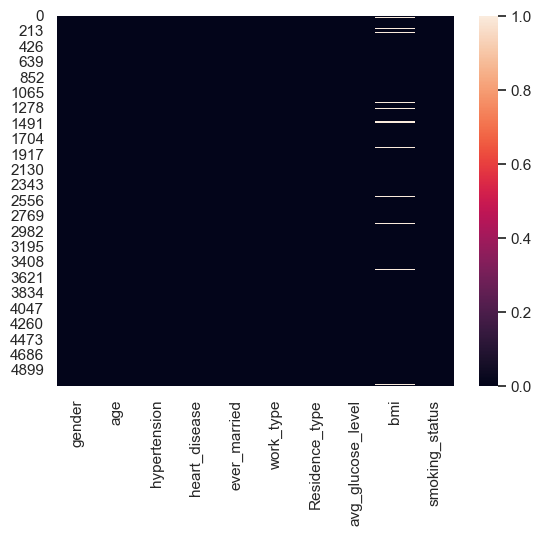

In [7]:
sns.heatmap(cdata.isnull())

In [8]:
cdata.isnull().sum()    

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
dtype: int64

In [9]:
cdata.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237
std,22.612647,0.296607,0.226063,45.283560,7.854067
min,0.080000,0.000000,0.000000,55.120000,10.300000
25%,25.000000,0.000000,0.000000,77.245000,23.500000
50%,45.000000,0.000000,0.000000,91.885000,28.100000
75%,61.000000,0.000000,0.000000,114.090000,33.100000
max,82.000000,1.000000,1.000000,271.740000,97.600000


In [10]:
cdata.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   str    
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   str    
 5   work_type          5110 non-null   str    
 6   Residence_type     5110 non-null   str    
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   str    
dtypes: float64(3), int64(2), str(5)
memory usage: 399.3 KB


### Data Profiling and Missing Value Detection
We perform a deeper dive into the dataset's structure and statistics:
* **`data.info()`** shows data types (float, int, object). `bmi` column has fewer non-null entries (4,909) than the total rows (5,110).
* **`data.describe()`** provides summary statistics.
* **`data.isnull().sum()`** All columns full except `bmi` has 201 null values will need imputing later.

In [11]:
cdata.nunique()

gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
dtype: int64

In [12]:
cols = cdata.select_dtypes('object').columns
for col in cols:
    print(f"--- {col} ---")
    print(cdata[col].value_counts())
    print("-" * 20)


--- gender ---
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64
--------------------
--- ever_married ---
ever_married
Yes    3353
No     1757
Name: count, dtype: int64
--------------------
--- work_type ---
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64
--------------------
--- Residence_type ---
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64
--------------------
--- smoking_status ---
smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64
--------------------


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_2856\1048067502.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols = cdata.select_dtypes('object').columns


In [13]:
cdata = cdata[cdata['gender'] != 'Other']

### Categorical Analysis and Anomaly Handling
Inspect the frequency distribution of categorical columns.
* `gender` column has only one instance of 'Other' better to drop.
* `smoking_status` has Unknown category, but it has the second-highest frequency better to leave as a category

In [14]:
%pip install sweetviz

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


c:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)



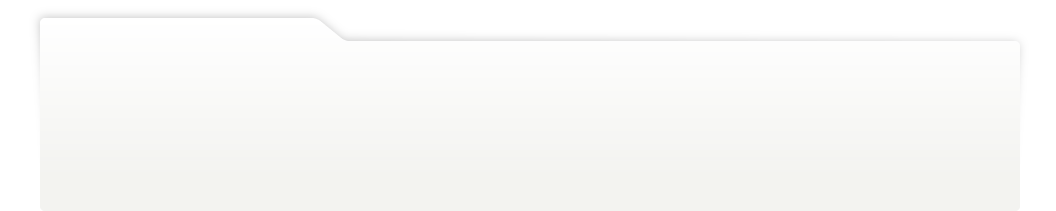
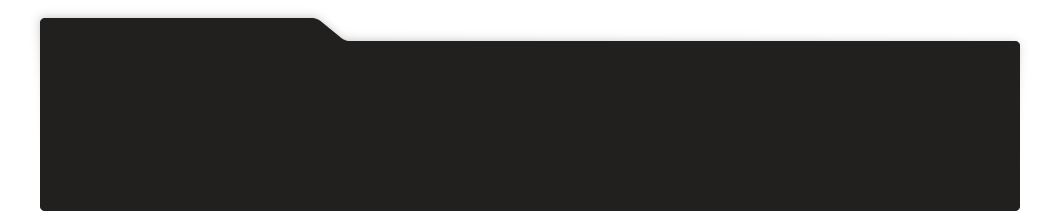
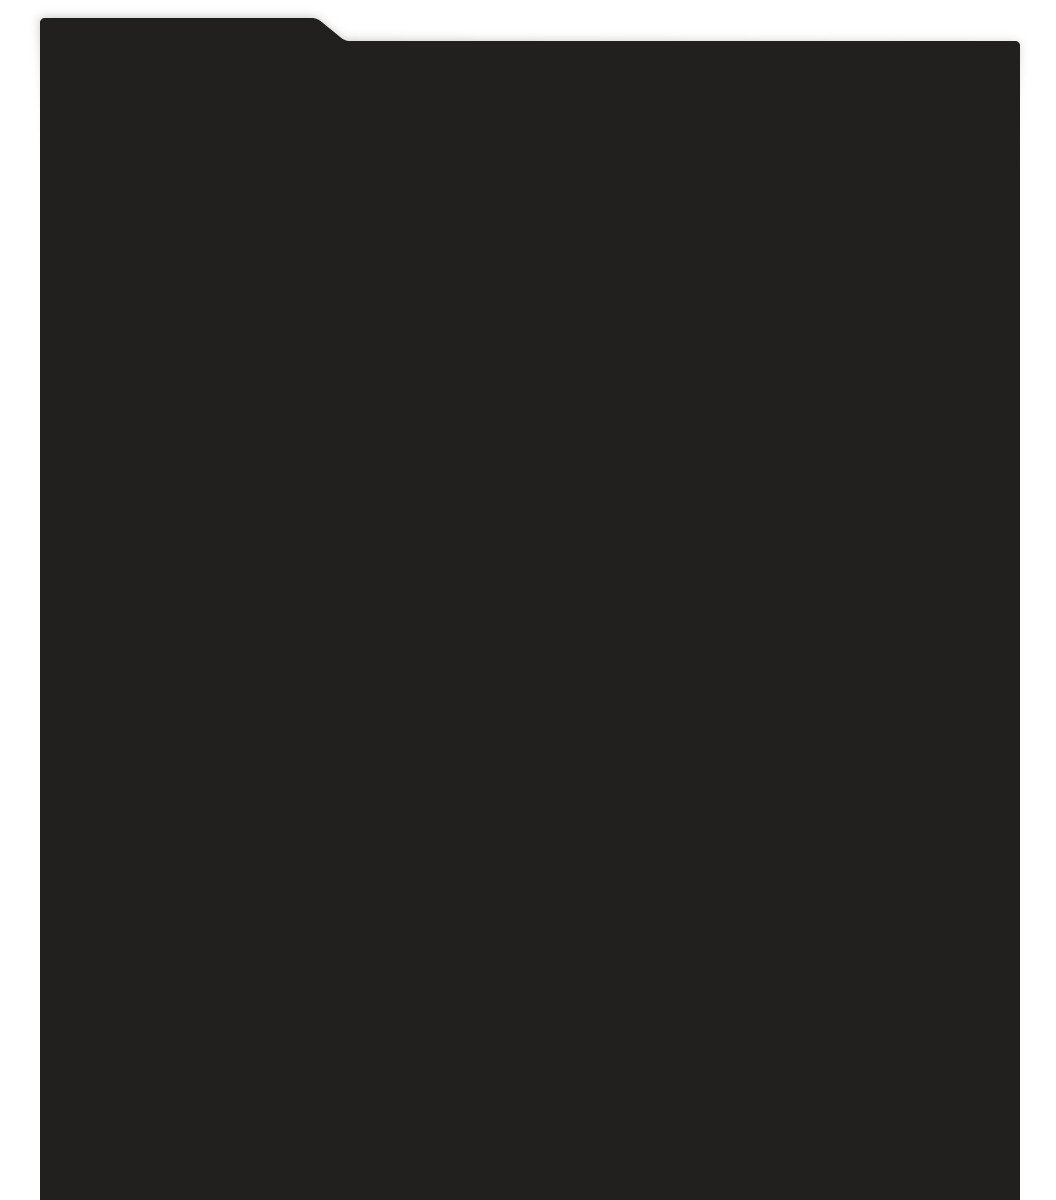
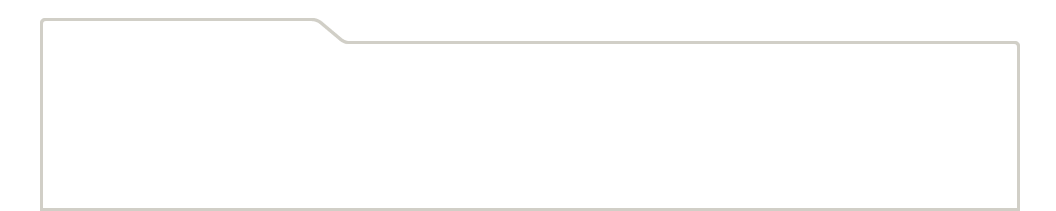
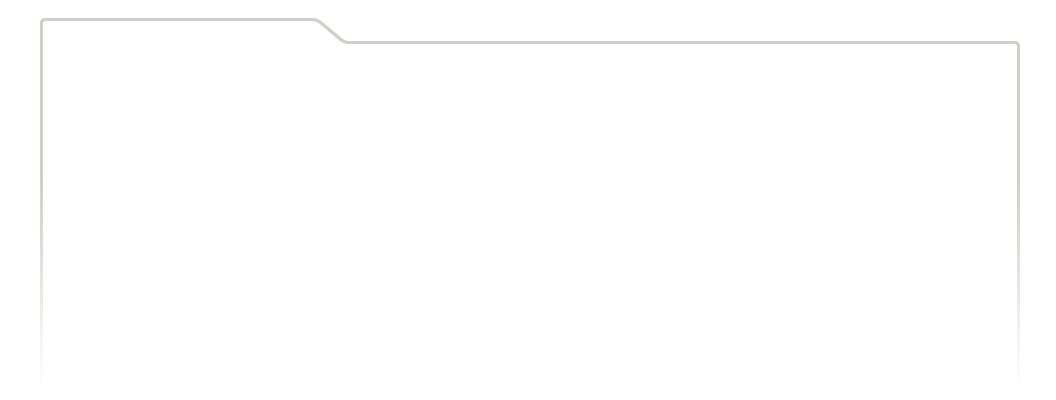
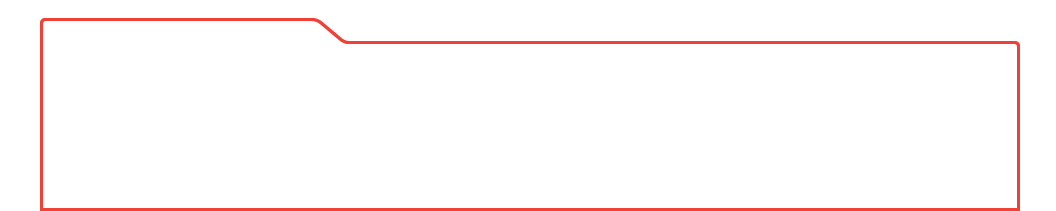
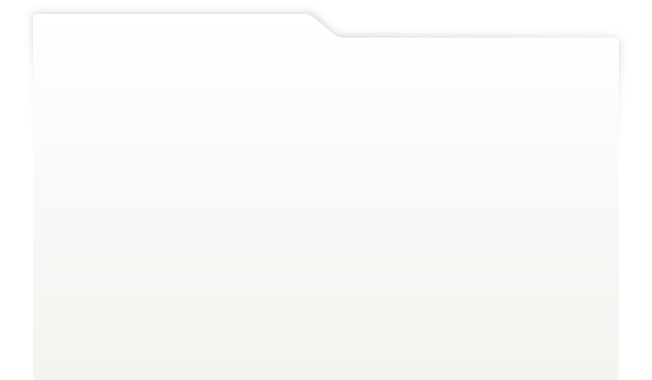
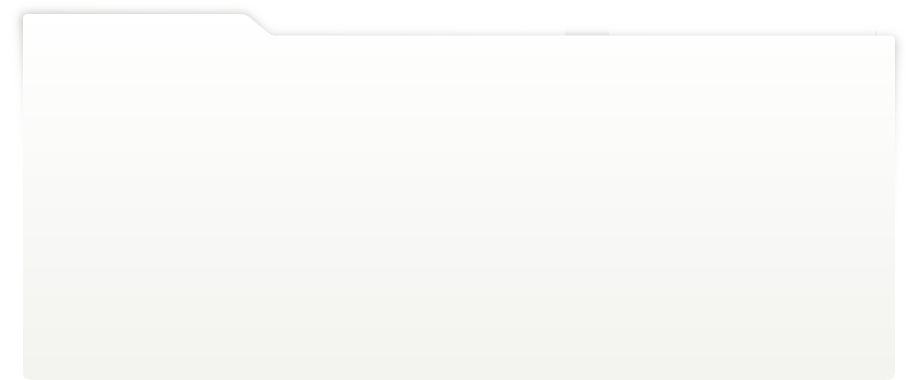
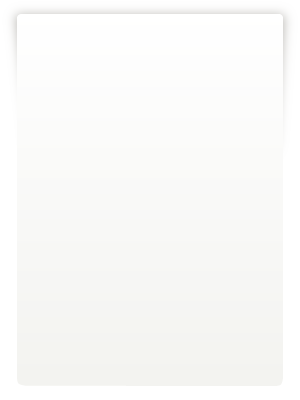
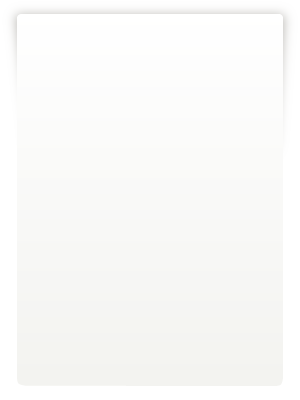
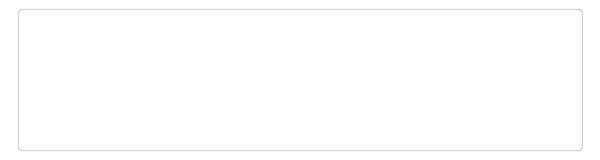
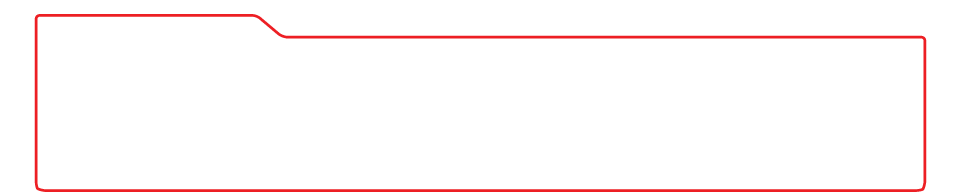
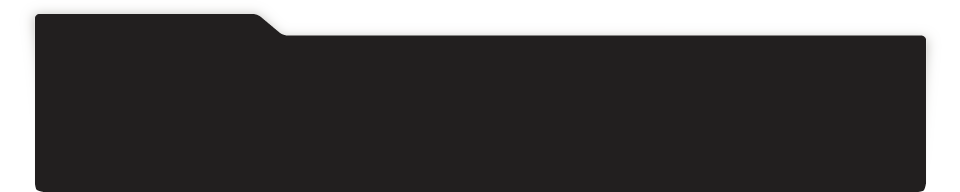
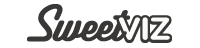
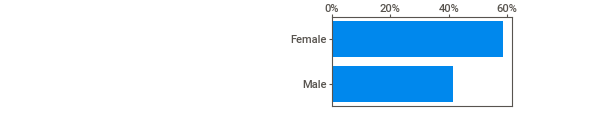
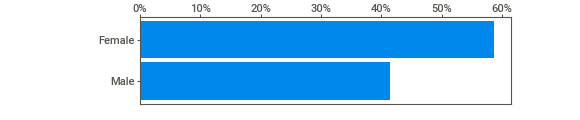
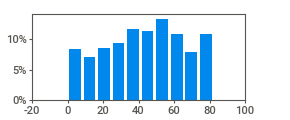
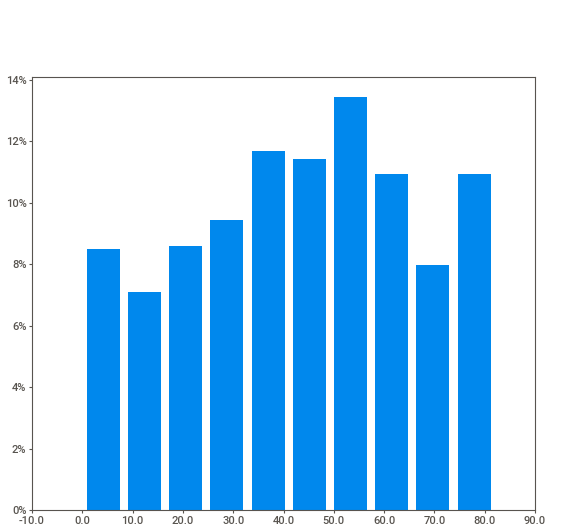
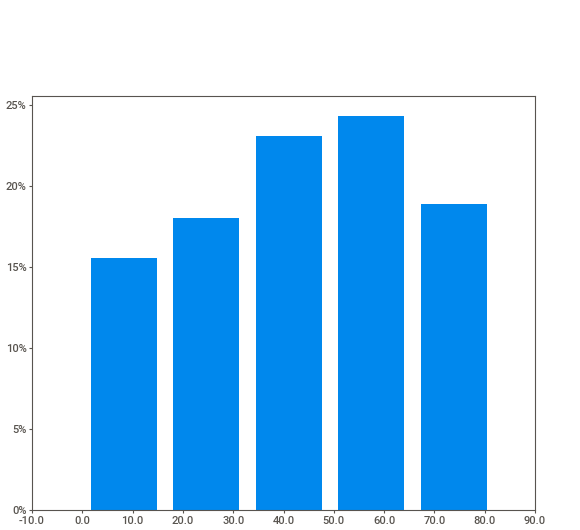
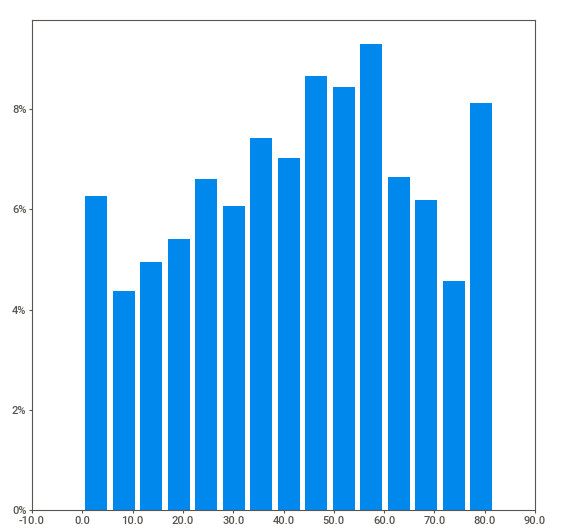
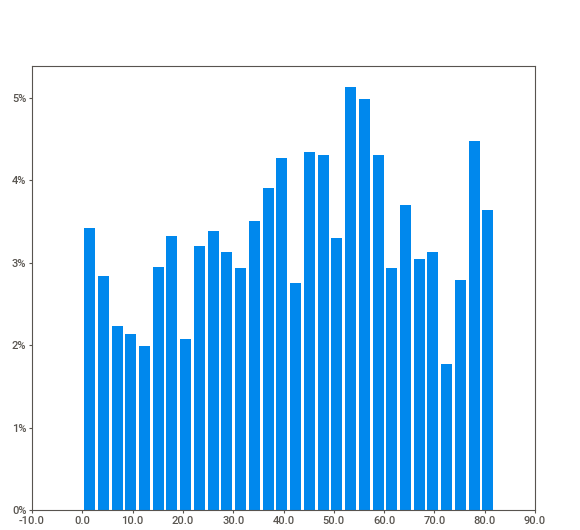
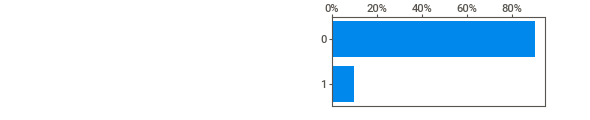
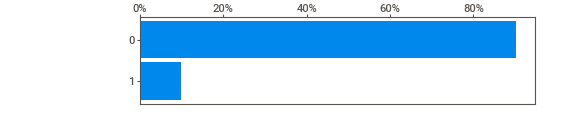
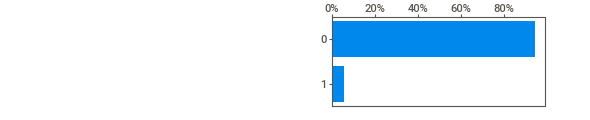
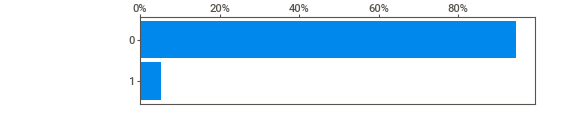
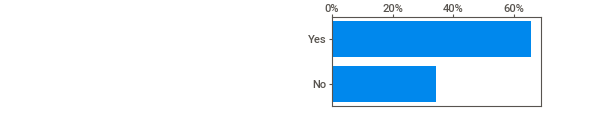
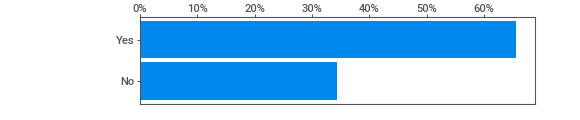
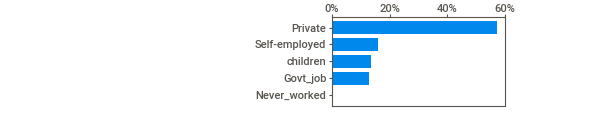
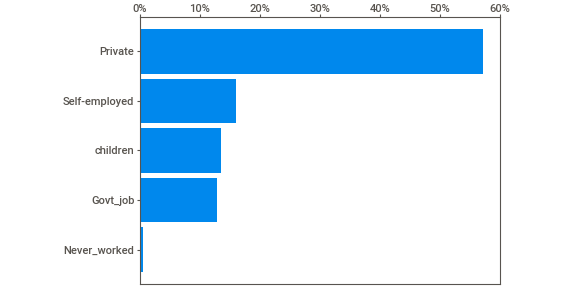
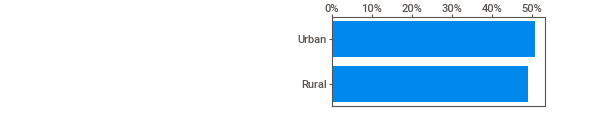
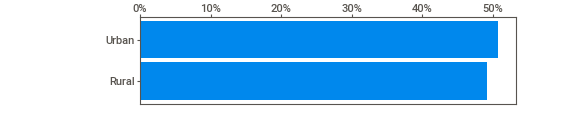
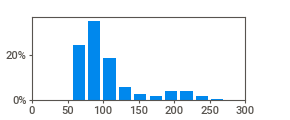
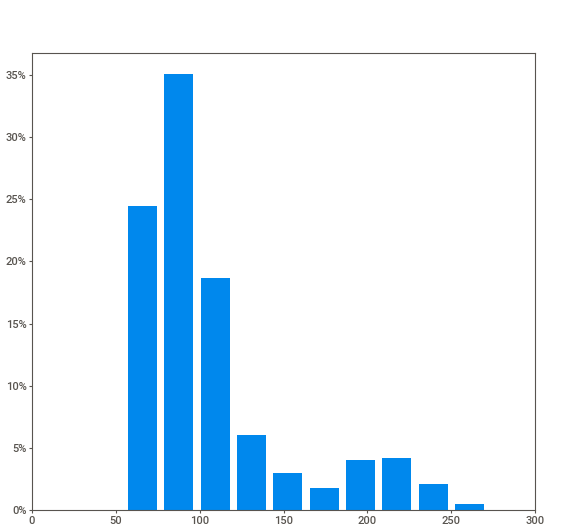
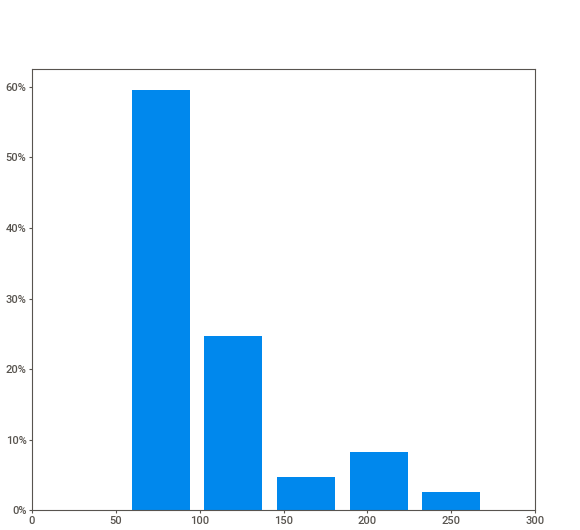
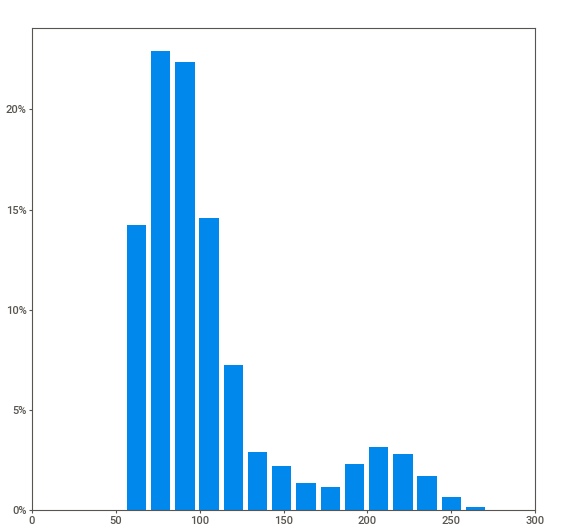
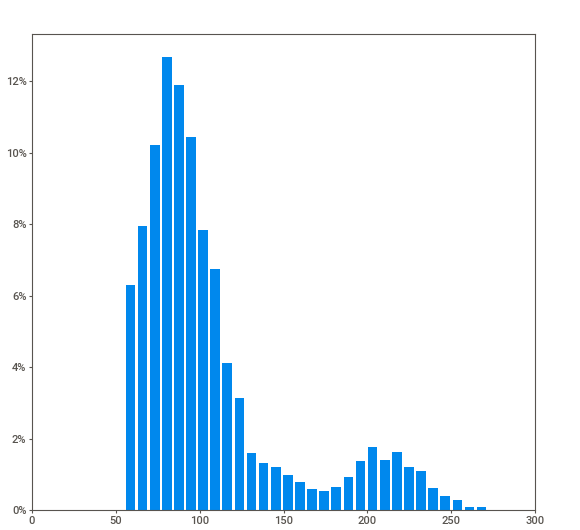
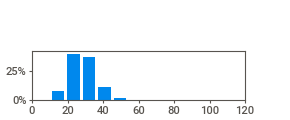
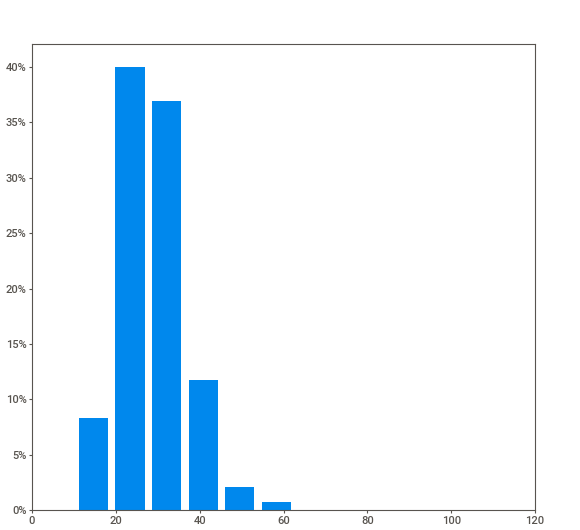
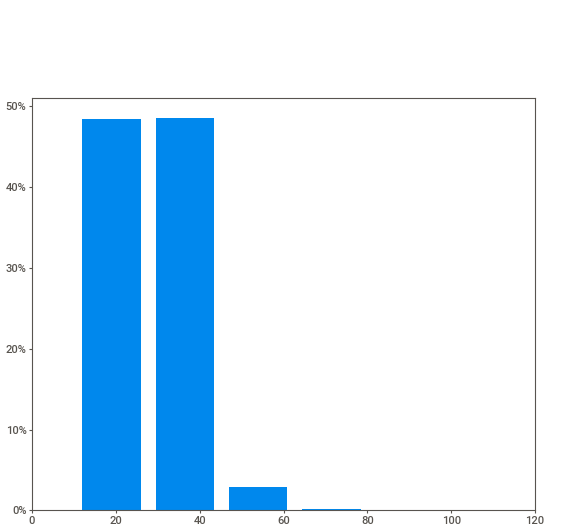
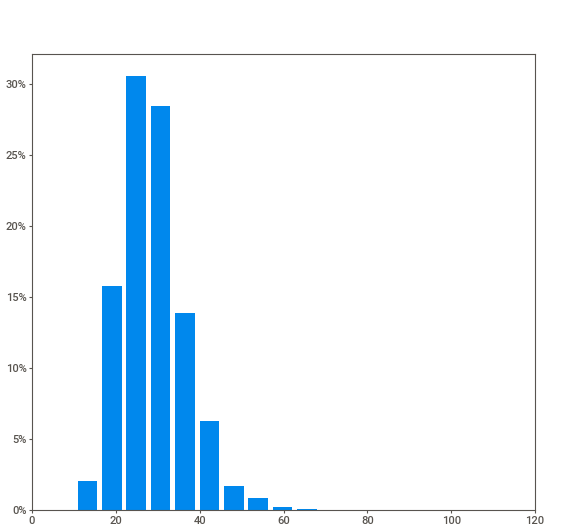
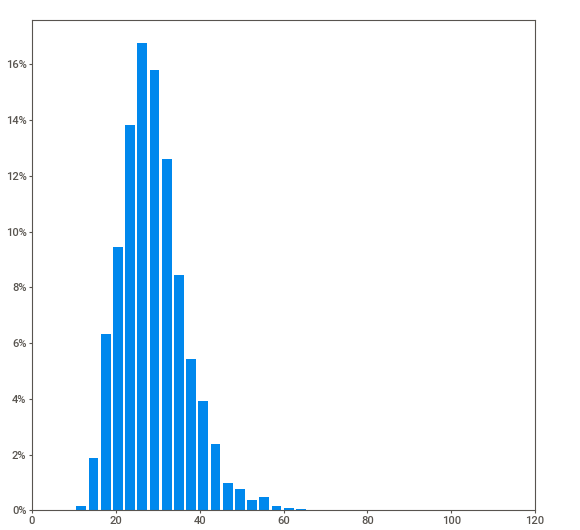
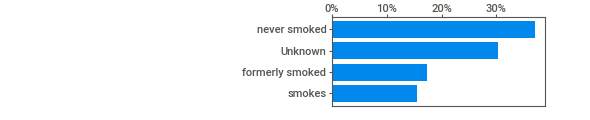
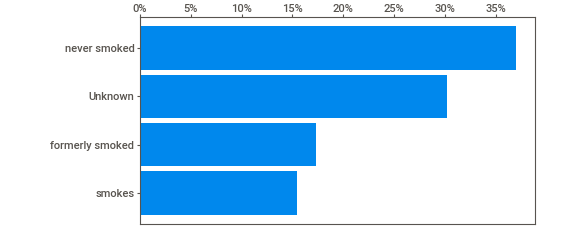
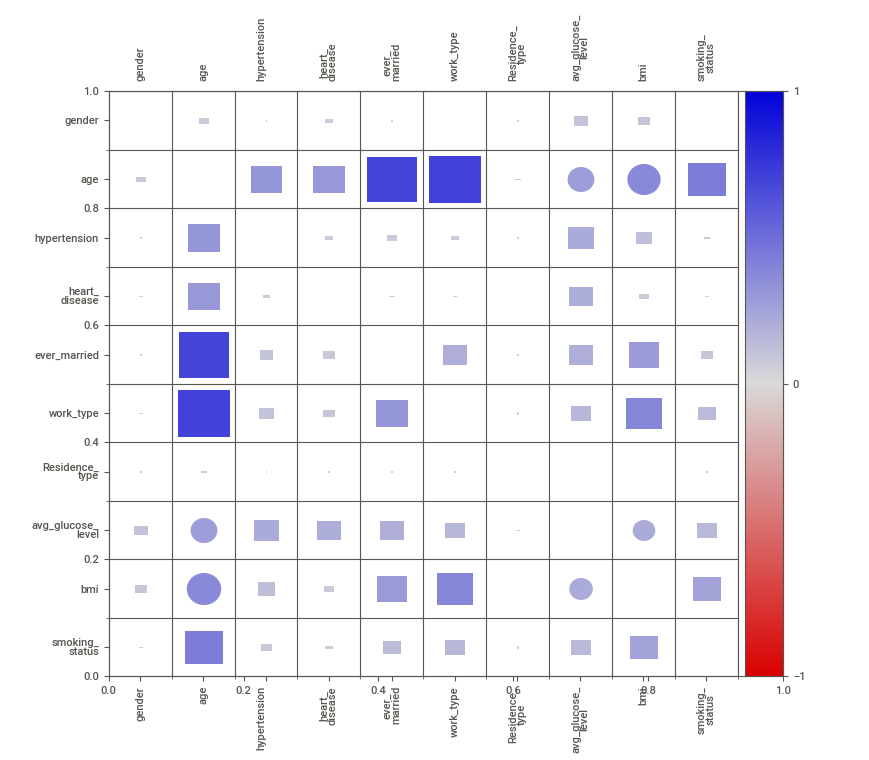
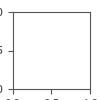

In [15]:
import sweetviz as sv

report = sv.analyze(cdata)
report.show_notebook()

###  Sweetviz: Automated Exploratory Data Analysis (EDA)

**Sweetviz** is an open-source Python library that performs comprehensive exploratory data analysis (EDA) with just a few lines of code, generating a high-density, interactive HTML report.

---

###  Key Features
*  Target Analysis: Shows how each column in the dataset affects the target variable you are trying to predict (e.g., heart disease).
*  Data Comparison: Allows you to compare two datasets (like `X_train` vs. `X_test`) to spot any bias or data drift.
*  Correlations: Intelligently integrates relationships between numerical and categorical variables in one single matrix.
*  Fast and Lightweight: Works efficiently right inside your Jupyter Notebook or can be exported as a standalone web page.

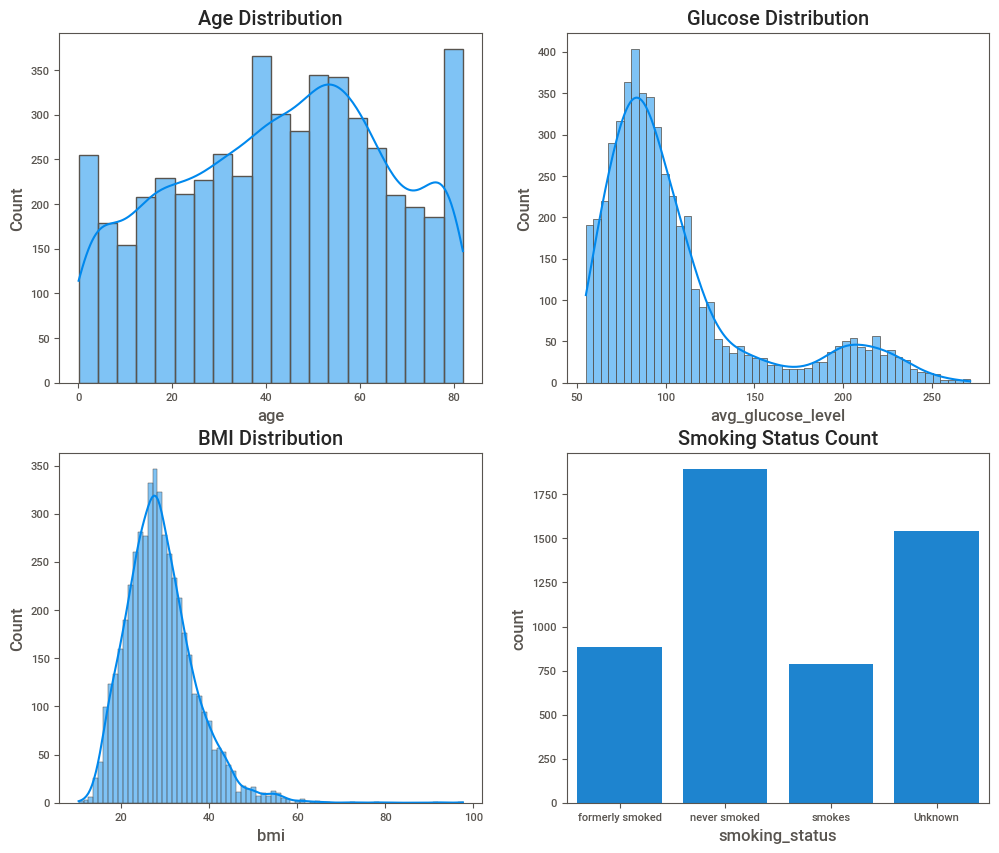

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.histplot(cdata['age'], ax=axes[0,0], kde=True).set_title('Age Distribution')
sns.histplot(cdata['avg_glucose_level'], ax=axes[0,1], kde=True).set_title('Glucose Distribution')
sns.histplot(cdata['bmi'], ax=axes[1,0], kde=True).set_title('BMI Distribution')
sns.countplot(data=cdata, x='smoking_status', ax=axes[1,1]).set_title('Smoking Status Count')
plt.show()

### Visualization: Feature Distributions
This figure reveals the underlying distribution of our continuous variables and a key categorical variable:
1. **Age Distribution (Top Left)**: The data is well distributed across all age groups, with a slight peak around (50-60 years).
2. **Glucose Distribution (Top Right)**: This distribution is heavily right-skewed. Most patients have an average glucose level between 70-110, with a secondary bump at higher levels (150-250), which likely represents the diabetic population in the dataset.
3. **BMI Distribution (Bottom Left)**: BMI follows a somewhat normal distribution but with a notable right skew, indicating a subset of patients with severe obesity (BMI > 40).
4. **Smoking Status (Bottom Right)**: The count plot shows that a large portion of the patients 'never smoked'. However, there is also a very high number of 'Unknown' records.

<Axes: >

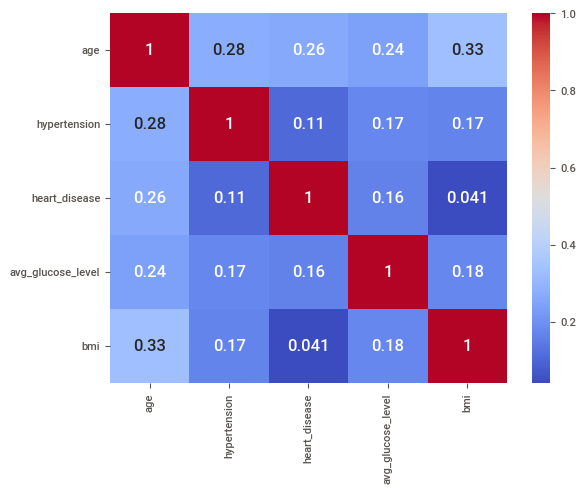

In [17]:
num_cols = cdata.select_dtypes(include=['int64', 'float64']).columns

sns.heatmap(cdata[num_cols].corr(), annot=True, cmap='coolwarm')

### Visualization: Feature Correlation Analysis
This heatmap displays the correlation between the numerical features in our dataset.
* **Key Insights**: We can see that the data mostly has no or very weak correlation with the highest correlation being 0.33 between `age` and `bmi`.

Text(0.5, 1.0, 'Glucose Level by Work Type')

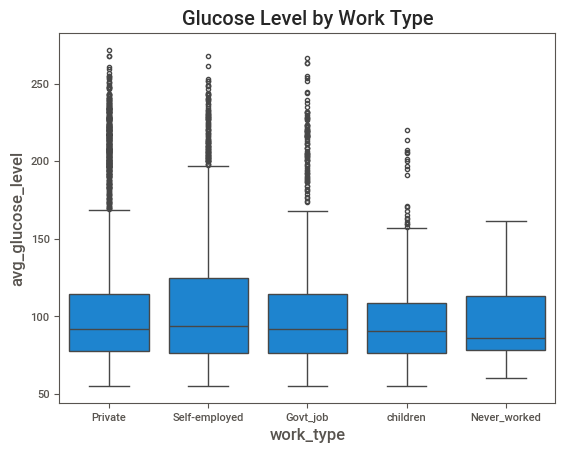

In [18]:
sns.boxplot(data=cdata, x='work_type', y='avg_glucose_level')
plt.title('Glucose Level by Work Type')

### Visualization: Average Glucose Level by Work Type
This box plot illustrates the distribution of `avg_glucose_level` across different `work_type` categories.
* **Category Variations**: There are noticeable differences between the groups. The `children` category exhibits lower average glucose levels and a very tight spread. In contrast, adult working categories (such as `Self-employed` or `Private`) tend to have higher medians and wider distributions.
* **Outlier Detection**: The dots extending beyond the top whiskers indicate patients with unusually high glucose levels.

Text(0.5, 1.0, 'Smoking Status by Residence Type')

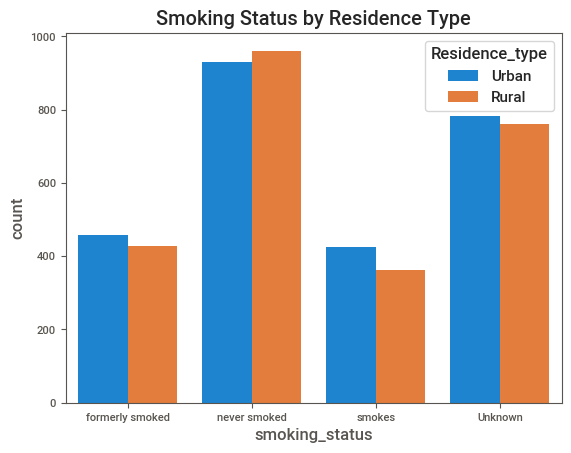

In [19]:
sns.countplot(data=cdata, x='smoking_status', hue='Residence_type')
plt.title('Smoking Status by Residence Type')

### Visualization: Smoking Status by Residence Type
This plot compares the distribution of patients' smoking habits across different living environments (Urban vs. Rural).
* **Key Observations**: This visualization highlights the significant difference in smoking habits between urban and rural living environments. Patients in rural areas are more likely to smoke, while those in urban areas tend to be more likely to not smoke.

In [20]:
cdata['age_bin'] = pd.cut(cdata['age'], bins=[0,10,20,30,40,50,60,70,85])
cdata['bmi'] = cdata['bmi'].fillna(cdata.groupby(['age_bin','gender'])['bmi'].transform('median'))
cdata = cdata.drop(columns='age_bin')

In [21]:
cdata['bmi'].isnull().sum()

np.int64(0)

In [22]:
cdata.duplicated().sum() 

np.int64(0)

### Data Transformation: Intelligent BMI Imputation
Instead of replacing the missing `bmi` values with a global average, we use a more appropriate approach.
* We create temporary `age_bins` (0-10, 10-20, etc.) because BMI has the strongest correlation with age.
* We then group the data by these age bins and fill the missing `bmi` values with the **median BMI of that specific age group**. The median is chosen over the mean because our previous distribution plot showed BMI is right-skewed, and the median is more resistant to outliers.

<Axes: ylabel='bmi'>

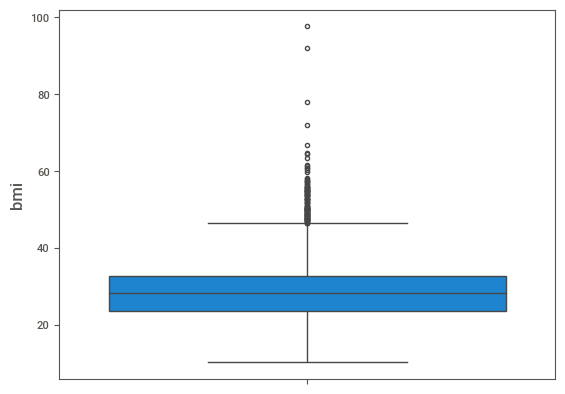

In [23]:
sns.boxplot(cdata['bmi'])

In [24]:
bmi_99 = cdata['bmi'].quantile(0.99)
cdata['bmi'] = cdata['bmi'].clip(upper=bmi_99)

<Axes: ylabel='bmi'>

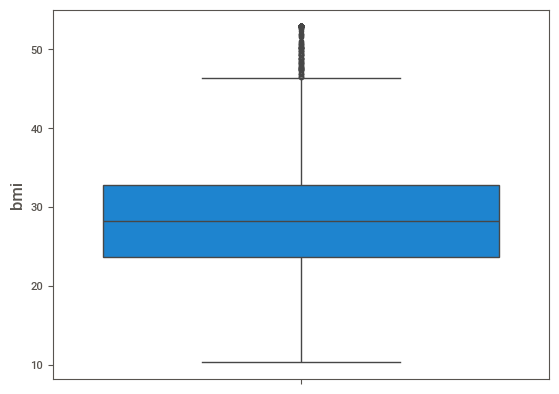

In [25]:
sns.boxplot(cdata['bmi'])

### Data Transformation: Outlier Detection and handling
* The boxplot for `bmi` visually highlights the spread of the data and identifies outliers.
* We remove the outliers above the 99th percentile, BMI above 50 is already level 3 morbidly obese, so above 60 is very unlikely.

In [26]:
le = LabelEncoder()
cdata['ever_married'] = le.fit_transform(cdata['ever_married'])
cdata['Residence_type'] = le.fit_transform(cdata['Residence_type'])
cdata['gender'] = cdata['gender'].map({'Male': 1, 'Female': 0})
cdata = pd.get_dummies(cdata, columns=['work_type', 'smoking_status'], dtype=int)

### Data Transformation: Encoding Categorical Variables
In this cell, we use Label Encoding and One Hot Encoding to convert our categorical text data into numerical format.
* **Justification**: We use `LabelEncoder` for `ever_married`, `Residence_type` and `gender` because they are binary variables that will be 1 or 0. And use `get_dummies` for `work_type` and `smoking_status` because they are multivalued and not ordinal.

In [27]:
scaler = StandardScaler()
X_scaled = cdata.copy()
scale_cols = ['age','bmi','avg_glucose_level']
X_scaled[scale_cols] = scaler.fit_transform(X_scaled[scale_cols])

X_scaled_array = X_scaled.values

In [28]:
X_scaled.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,1,1.051242,0,1,1,1,2.706450,1.044839,0,0,1,0,0,0,1,0,0
1,0,0.785889,0,0,1,0,2.121652,0.119271,0,0,0,1,0,0,0,1,0
2,1,1.626174,0,1,1,0,-0.004867,0.494863,0,0,1,0,0,0,0,1,0
3,0,0.255182,0,0,1,1,1.437473,0.749730,0,0,1,0,0,0,0,0,1
4,0,1.581949,1,0,1,0,1.501297,-0.645329,0,0,0,1,0,0,0,1,0


### Data Transformation: Feature Scaling
Here, we apply a `StandardScaler` to our feature set before feeding it into our dimensionality reduction and modeling pipelines.
* **Justification**: If we look at our earlier data exploration, features have different scales. `avg_glucose_level` ranges from ~55 to 271, `age` goes up to 82, while our encoded categorical variables are 0 or 1. So we scale the values so that our algorithm isn't biased towards features with higher magnitudes.

In [29]:
pca = PCA(n_components=0.85, random_state=42)
X_pca = pca.fit_transform(X_scaled_array)

In [30]:
X_pca.shape[1]   

7

### Dimensionality Reduction: PCA
We apply Principal Component Analysis (PCA) to the standardized numerical features.
* The parameter `n_components=0.85` dictates that the algorithm should keep exactly as many principal components as needed to explain **85% of the variance** in the original data.
* The output reveals that the data was reduced to **7 principal components**. This transformation reduces the dimensionality while preserving the vast majority of the information and underlying patterns in the dataset.

In [31]:
!pip install scikit-learn-extra


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


K-Medoids Clustering

For the K-Medoids clustering algorithm, we first select a set of relevant numerical features from the dataset, including age, average glucose level, BMI, hypertension, and heart disease. These features are chosen because they provide meaningful information about the patients’ health conditions.

Since K-Medoids is a distance-based clustering method, it is sensitive to differences in feature scales. To ensure that no feature dominates the distance calculation, we apply StandardScaler to normalize all selected features to a common scale.

After scaling, the transformed dataset is used as input to the K-Medoids algorithm for clustering analysis.

## k_Medoids

For the K-Medoids clustering algorithm, we first select a set of relevant numerical features from the dataset, including age, average glucose level, BMI, hypertension, and heart disease. These features are chosen because they represent important information about patients’ health conditions.

Since K-Medoids is a distance-based clustering method, it is sensitive to differences in feature scales. Therefore, we apply StandardScaler to normalize all selected features to a common scale, ensuring that each feature contributes equally to the distance calculations.

After scaling, the transformed dataset is used as input to the K-Medoids algorithm for clustering analysis.

In [32]:
from sklearn_extra.cluster import KMedoids


In [33]:
features = cdata[['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease']].values

scaler = StandardScaler()
features = scaler.fit_transform(features)

## K-Medoids Elbow Method

To determine the optimal number of clusters for the K-Medoids algorithm, we use the Elbow Method. In this step, we run the K-Medoids algorithm for different values of K (from 2 to 7) and compute the corresponding inertia (clustering cost) for each value.

For each K, the model is fitted on the preprocessed feature set, and the inertia value is recorded. Inertia represents the total dissimilarity between data points and their assigned medoids, measured using the Manhattan distance metric.

Finally, we plot the values of K against their corresponding inertia values. The optimal number of clusters is selected at the point where the decrease in inertia starts to slow down significantly (the “elbow point”), indicating a good balance between model complexity and clustering performance.


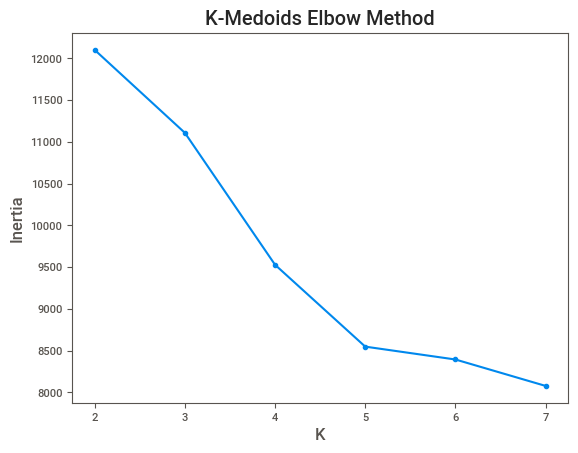

In [34]:

from sklearn_extra.cluster import KMedoids
import matplotlib.pyplot as plt

K = range(2, 8)
inertia = []

for k in K:
    model = KMedoids(n_clusters=k, metric="manhattan", init="random", random_state=42)
    model.fit(features)
    inertia.append(model.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("K-Medoids Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")
plt.show()


## Silhouette Score for K-Medoids Clustering

To evaluate the quality of clustering produced by the K-Medoids algorithm, we use the Silhouette Score. This metric measures how similar each data point is to its own cluster compared to other clusters, providing an indication of cluster cohesion and separation.

We test different values of K (from 2 to 7) by fitting a K-Medoids model for each value and assigning cluster labels to the dataset. For each K, the Silhouette Score is computed using the resulting cluster labels.

Finally, we plot the Silhouette Scores against the different values of K. The optimal number of clusters is chosen as the value of K that achieves the highest Silhouette Score, indicating well-separated and well-defined clusters.


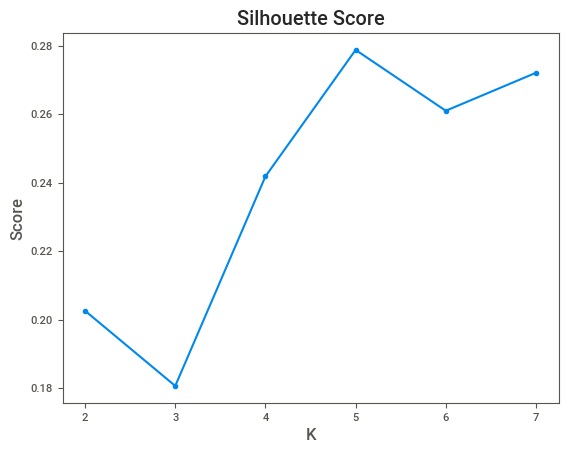

In [35]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

scores = []

for k in K:
    model = KMedoids(n_clusters=k, metric="manhattan", init="random", random_state=42)
    labels_temp = model.fit_predict(features)

    score = silhouette_score(features, labels_temp)
    scores.append(score)

plt.plot(K, scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

## K-Medoids Final Model Fitting

After determining the optimal number of clusters using the Elbow Method and Silhouette Score, we train the final K-Medoids clustering model.

In this step, we initialize the K-Medoids algorithm with the selected number of clusters (K = 3), using the Manhattan distance metric and random initialization. The model is then fitted on the preprocessed feature set.

After training, each data point is assigned to one of the clusters, and the cluster labels are extracted from the model. These labels represent the final grouping of the data based on similarity in the feature space.


In [36]:
kmedoids = KMedoids(n_clusters=3, metric="manhattan", init="random", random_state=42)

kmedoids.fit(features)

labels = kmedoids.labels_



## Cluster Analysis and Interpretation

After applying the K-Medoids clustering algorithm, the resulting cluster labels are added to the original dataset as a new column named *cluster*. This allows each data point to be associated with its corresponding cluster.

To better understand the characteristics of each cluster, we compute the mean values of the selected features (age, average glucose level, BMI, hypertension, and heart disease) for each cluster group. This is done using groupby aggregation on the cluster labels.

The resulting summary provides insight into the differences between clusters, helping to interpret how patient profiles vary across the identified groups.


In [37]:

cdata['cluster'] = labels

cdata.groupby('cluster')[[
    'age',
    'avg_glucose_level',
    'bmi',
    'hypertension',
    'heart_disease'
]].mean()

,age,avg_glucose_level,bmi,hypertension,heart_disease
cluster,,,,,
0,17.075428,94.181656,21.660438,0.001369,0.002053
1,41.721475,92.149566,34.777368,0.088043,0.022606
2,63.945602,126.979400,29.022866,0.176919,0.119471


## Hierarchical Clustering (Single Linkage Dendogram)

To further analyze the structure of the dataset, we apply Hierarchical Clustering and visualize the relationships between data points using a dendrogram.

In this step, we use the single linkage method to compute the hierarchical relationships between samples based on their distance in the feature space. The linkage process merges data points step by step according to their similarity, forming a tree-like structure.

The dendrogram is then plotted to visually represent how clusters are formed at different distance levels. This helps in understanding the hierarchy of the data and can also be used to decide an appropriate number of clusters by observing where the largest distance gaps occur.


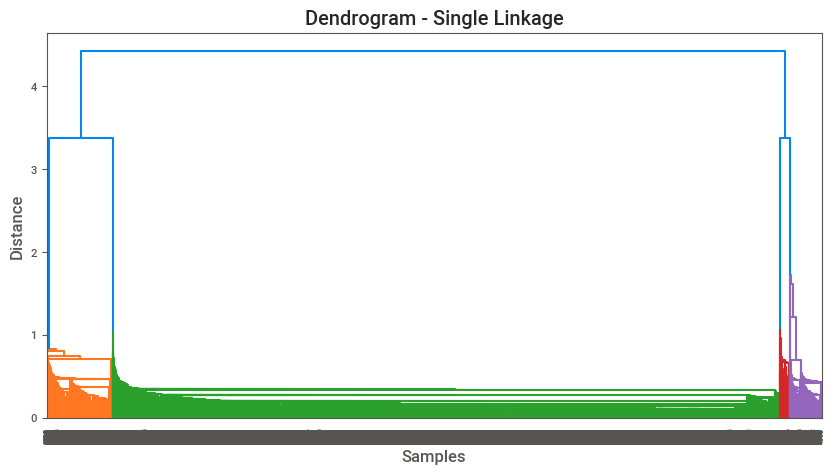

In [38]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sch.dendrogram(sch.linkage(features, method='single'))
plt.title("Dendrogram - Single Linkage")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()



## Hierarchical Clustering (Complete Linkage Dendrogram)

To further explore the structure of the dataset, we apply Hierarchical Clustering using the complete linkage method and visualize the results with a dendrogram.

In complete linkage, the distance between two clusters is defined as the maximum distance between their data points. This method tends to produce more compact and well-separated clusters compared to single linkage.

The dendrogram illustrates how individual data points are progressively merged into larger clusters based on their distances. This visualization helps in understanding the hierarchical structure of the data and can assist in selecting an appropriate number of clusters by identifying significant jumps in distance.


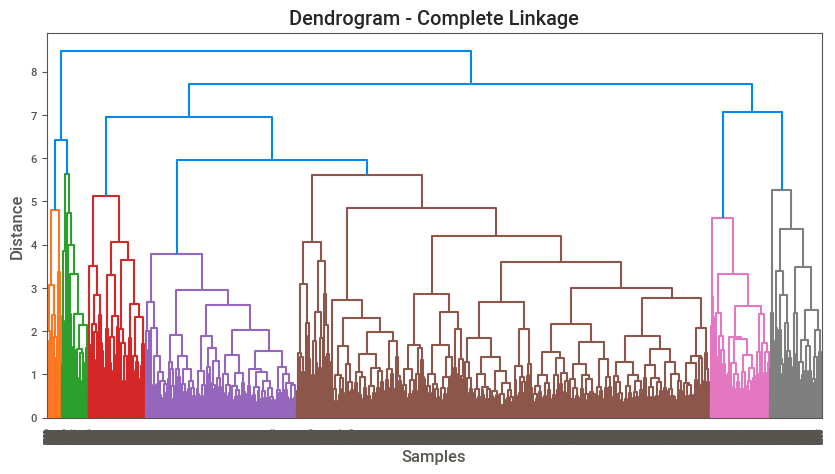

In [39]:
plt.figure(figsize=(10,5))
sch.dendrogram(sch.linkage(features, method='complete'))
plt.title("Dendrogram - Complete Linkage")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

## Hierarchical Clustering (Average Linkage Dendrogram)

To further analyze the structure of the dataset, we apply Hierarchical Clustering using the average linkage method and visualize it using a dendrogram.

In average linkage, the distance between two clusters is calculated as the average distance between all pairs of data points in the two clusters. This method provides a balanced approach between single and complete linkage, producing more stable clustering results.

The dendrogram visualizes how data points are progressively merged into clusters based on their similarity. It helps in understanding the hierarchical relationships in the dataset and can be used to estimate a suitable number of clusters by observing significant distance gaps.


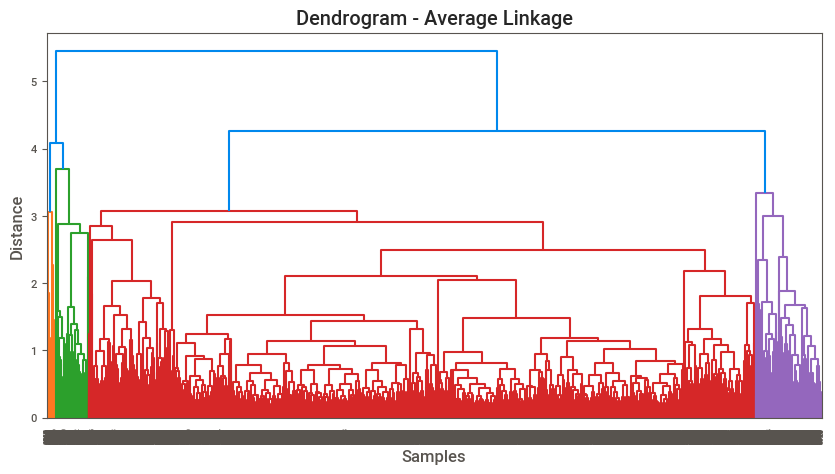

In [40]:
plt.figure(figsize=(10,5))
sch.dendrogram(sch.linkage(features, method='average'))
plt.title("Dendrogram - Average Linkage")
plt.xlabel("Samples")
plt.ylabel("Distance")
plt.show()

## Hierarchical Clustering (Agglomerative Model)

To perform hierarchical clustering on the dataset, we use the Agglomerative Clustering algorithm. This is a bottom-up approach where each data point starts as its own cluster, and clusters are progressively merged based on similarity until the desired number of clusters is reached.

In this implementation, we set the number of clusters to 3 and use the Euclidean distance metric with the complete linkage method. Complete linkage considers the maximum distance between points in different clusters when deciding which clusters to merge, resulting in more compact and well-separated clusters.

After fitting the model, each data point is assigned a cluster label. These labels are then added to the original dataset as a new column named *cluster_hierarchical*, allowing further analysis and comparison of the formed clusters.


In [41]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=3,
    metric='euclidean',
    linkage='complete'
)

labels_h = hc.fit_predict(features)

cdata['cluster_hierarchical'] = labels_h

## Silhouette Score for Hierarchical Clustering

To evaluate the quality of the clusters produced by the Hierarchical Clustering model, we use the Silhouette Score. This metric measures how well each data point fits within its assigned cluster compared to other clusters.

The score is computed using the feature set and the cluster labels generated by the Agglomerative Clustering model. A higher Silhouette Score indicates better-defined and more well-separated clusters, while a lower score suggests overlapping or poorly separated clusters.

This evaluation helps validate the effectiveness of the hierarchical clustering results and provides insight into the quality of the chosen clustering configuration.


In [42]:
from sklearn.metrics import silhouette_score

print("Hierarchical Silhouette Score:",
      silhouette_score(features, labels_h))

Hierarchical Silhouette Score: 0.2828635989980915


## Hierarchical Clustering Results Interpretation

To interpret the results of the Hierarchical Clustering model, we analyze the characteristics of each cluster by computing the mean values of the selected features. These features include age, average glucose level, BMI, hypertension, and heart disease.

The dataset is grouped based on the assigned hierarchical cluster labels, and the average values for each feature are calculated within each cluster. This helps to summarize the main characteristics of each group and understand how patients differ across clusters.

By comparing these averages, we can identify patterns and differences between clusters, which provides meaningful insights into the structure of the data and the relationships between the selected health features.


In [43]:
cdata.groupby('cluster_hierarchical')[[
    'age',
    'avg_glucose_level',
    'bmi',
    'hypertension',
    'heart_disease'
]].mean()

,age,avg_glucose_level,bmi,hypertension,heart_disease
cluster_hierarchical,,,,,
0,45.125512,144.201774,39.753195,0.076398,0.0
1,68.188406,136.818768,30.186384,0.231884,1.0
2,41.210976,97.270590,26.761976,0.092195,0.0


In [44]:
#~FUZZY~

In [45]:
# Create a dictionary for mapping

cluster_names = {
    2: 'Low Risk',
    0: 'Moderate Risk',
    1: 'High Risk'
}

# Apply the names to a new column
cdata['risk_profile'] = cdata['cluster_hierarchical'].map(cluster_names)

# Now when you group, it will show the names instead of 0, 1, 2
print(cdata.groupby('risk_profile')[['age', 'avg_glucose_level', 'bmi']].mean())

                     age  avg_glucose_level        bmi
risk_profile                                          
High Risk      68.188406         136.818768  30.186384
Low Risk       41.210976          97.270590  26.761976
Moderate Risk  45.125512         144.201774  39.753195


In [46]:
!pip install scikit-fuzzy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np

In [48]:
# This shows the min and max for your specific inputs
print(cdata[['age', 'avg_glucose_level', 'bmi']].agg(['min', 'max']))

       age  avg_glucose_level     bmi
min   0.08              55.12  10.300
max  82.00             271.74  52.892


In [49]:
#inputs~np.arange(min,max,steps)
#pick most imp features from heatmap(age,avg_glucose_level,bmi)
age= ctrl.Antecedent(np.arange(0, 83,1), 'age')
avg_glucose_level= ctrl.Antecedent(np.arange(55, 273,1), 'avg_glucose_level')
bmi= ctrl.Antecedent(np.arange(10, 54,1), 'bmi')

In [50]:
#output(from the cluster)
#cluster range is from 0(min) to 1(max)
risk_level = ctrl.Consequent(np.arange(0, 1.1, 0.1), 'risk_level')

In [51]:
# Membership functions
age['young'] = fuzz.trapmf(age.universe, [0, 0, 30, 45])
age['middle_aged'] = fuzz.trimf(age.universe, [35, 50, 65])
age['senior'] = fuzz.trapmf(age.universe, [60, 75, 82, 82])

avg_glucose_level['normal'] = fuzz.trapmf(avg_glucose_level.universe, [55, 55, 90, 110])
avg_glucose_level['elevated'] = fuzz.trimf(avg_glucose_level.universe, [100, 144, 180])
avg_glucose_level['high'] = fuzz.trapmf(avg_glucose_level.universe, [170, 220, 272, 272])

bmi['normal'] = fuzz.trapmf(bmi.universe, [10, 10, 25, 30])
bmi['obese'] = fuzz.trapmf(bmi.universe, [28, 35, 54, 54]) 

# Universe range: [0, 1]  (cluster membership values)
#
# Design logic:
#   We place 3 symmetric triangles across [0, 1]:
#
#     Step 1 : pick the center of 'moderate' = 0.5  (midpoint of universe)
#     Step 2 : shift left  by 0.3 : center of 'low'  = 0.2
#            : shift right by 0.3 : center of 'high'  = 0.8
#     Step 3 : each triangle spans 0.4 units (0.2 on each side of its peak)
#              derived from:  0 + x/2 = 0.2  :  x = 0.4  (for 'low')
#              same width is mirrored for 'moderate' and 'high'

risk_level['low'] = fuzz.trimf(risk_level.universe, [0, 0.2, 0.4])
risk_level['moderate'] = fuzz.trimf(risk_level.universe, [0.3, 0.5, 0.7])
risk_level['high'] = fuzz.trimf(risk_level.universe, [0.6, 0.8, 1.0])

# --- CLUSTER-TO-RULE MAPPING REFERENCE ---
# [CL2] LOW RISK: Age~41 | Glu~97  | BMI~26 | HD: 0.0 -> Healthy Baseline
# [CL0] MOD RISK: Age~45 | Glu~144 | BMI~39 | HD: 0.0 -> Obesity Warning
# [CL1] HIG RISK: Age~68 | Glu~136 | BMI~30 | HD: 1.0 -> High Risk Anchor
#
# LOGIC: BMI acts as a 'Risk Toggle'. 
# - Normal BMI: Compensates for Age/Glu (Risk Level -1)
# - Obese BMI: Multiplies risk markers (Risk Level +1)
# ----------------------------------------

In [52]:
# ==============================================================================
# RULE LOGIC DERIVATION (Based on Hierarchical Cluster Means)
# ==============================================================================
# I used the Cluster Centroids (Means) to determine the 'THEN' (consequent) part:
# 
# 1. CLUSTER 2 (Low Risk): Mean Age ~41, Glucose ~97, BMI ~26. 
#    - Result: Heart Disease 0.0. 
#    - Logic: When all features are Low/Normal, the result is 'Low Risk'.
#
# 2. CLUSTER 0 (Moderate Risk): Mean Age ~45, Glucose ~144, BMI ~39.
#    - Result: Heart Disease 0.0 (Pre-clinical). 
#    - Logic: High BMI/Glucose acts as a 'Warning'. Even if Heart Disease is 0.0,
#      the risk shifts to 'Moderate' to reflect physical strain.
#
# 3. CLUSTER 1 (High Risk): Mean Age ~68, Glucose ~136, BMI ~30.
#    - Result: Heart Disease 1.0. 
#    - Logic: Senior age combined with elevated markers results in 'High Risk'.
#
# ------------------------------------------------------------------------------
# 18-RULE MATRIX STRUCTURE:
# - Layer 1 (Normal BMI): Baseline risk. Normal BMI acts as a 'protective' factor
#   stepping down risk for Young/Middle-aged patients (Compensatory Logic).
# - Layer 2 (Obese BMI): Risk multiplier. High BMI shifts the baseline risk 
#   upward (e.g., Low -> Moderate) across all age/glucose combinations.
# ==============================================================================

In [53]:

# --- Layer 1: Normal BMI  ---

rule1 = ctrl.Rule(age['young'] & avg_glucose_level['normal'] & bmi['normal'], risk_level['low'])
rule2 = ctrl.Rule(age['young'] & avg_glucose_level['elevated'] & bmi['normal'], risk_level['low'])
rule3 = ctrl.Rule(age['young'] & avg_glucose_level['high'] & bmi['normal'], risk_level['moderate'])

rule4 = ctrl.Rule(age['middle_aged'] & avg_glucose_level['normal'] & bmi['normal'], risk_level['low'])
rule5 = ctrl.Rule(age['middle_aged'] & avg_glucose_level['elevated'] & bmi['normal'], risk_level['moderate'])
rule6 = ctrl.Rule(age['middle_aged'] & avg_glucose_level['high'] & bmi['normal'], risk_level['moderate'])

rule7 = ctrl.Rule(age['senior'] & avg_glucose_level['normal'] & bmi['normal'], risk_level['moderate'])
rule8 = ctrl.Rule(age['senior'] & avg_glucose_level['elevated'] & bmi['normal'], risk_level['high'])
rule9 = ctrl.Rule(age['senior'] & avg_glucose_level['high'] & bmi['normal'], risk_level['high'])



# --- Layer 2: Obese BMI (Risk Multiplier) ---

rule10 = ctrl.Rule(age['young'] & avg_glucose_level['normal'] & bmi['obese'], risk_level['moderate'])
rule11 = ctrl.Rule(age['young'] & avg_glucose_level['elevated'] & bmi['obese'], risk_level['moderate'])
rule12 = ctrl.Rule(age['young'] & avg_glucose_level['high'] & bmi['obese'], risk_level['high'])

rule13 = ctrl.Rule(age['middle_aged'] & avg_glucose_level['normal'] & bmi['obese'], risk_level['moderate'])
rule14 = ctrl.Rule(age['middle_aged'] & avg_glucose_level['elevated'] & bmi['obese'], risk_level['high'])
rule15 = ctrl.Rule(age['middle_aged'] & avg_glucose_level['high'] & bmi['obese'], risk_level['high'])

rule16 = ctrl.Rule(age['senior'] & avg_glucose_level['normal'] & bmi['obese'], risk_level['high'])
rule17 = ctrl.Rule(age['senior'] & avg_glucose_level['elevated'] & bmi['obese'], risk_level['high'])
rule18 = ctrl.Rule(age['senior'] & avg_glucose_level['high'] & bmi['obese'], risk_level['high'])

### Layer 1:Normal BMI Logic 

AGE/GLOUCOSE table when BMI is **Normal**
(doesn't change any thing just  lower the value of 2 cells )

| Age \ Avg Glucose Level | Normal | Elevated | High |
| :--- | :---: | :---: | :---: |
| **Young** | Low | **Low*** | Moderate |
| **Mid-Aged** | Low | Moderate | **Moderate*** |
| **Senior** | Moderate | High | High |

### Layer 2: Obese BMI Logic (Risk Multiplier)

( level up all the values )
In this layer, the patient is **Obese**. This high BMI acts as a risk multiplier, shifting the baseline risk upward across all categories.

| Age \ Avg Glucose Level | Normal | Elevated | High |
| :--- | :---: | :---: | :---: |
| **Young** | Moderate | Moderate | High |
| **Mid-Aged** | Moderate | High | High |
| **Senior** | High | High | High |

In [54]:
# Control system
risk_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9 , rule10, rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18])
risk_sim = ctrl.ControlSystemSimulation(risk_ctrl)

In [55]:
# Input values (Example: Elderly patient with high glucose)
risk_sim.input['age'] = 70
risk_sim.input['avg_glucose_level'] = 210
risk_sim.input['bmi'] = 35

In [56]:
# Compute
risk_sim.compute()

In [57]:
risk_score_val=risk_sim.output['risk_level']
print(f"Risk Score : {round(risk_score_val, 1)} %")

Risk Score : 0.8 %


c:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


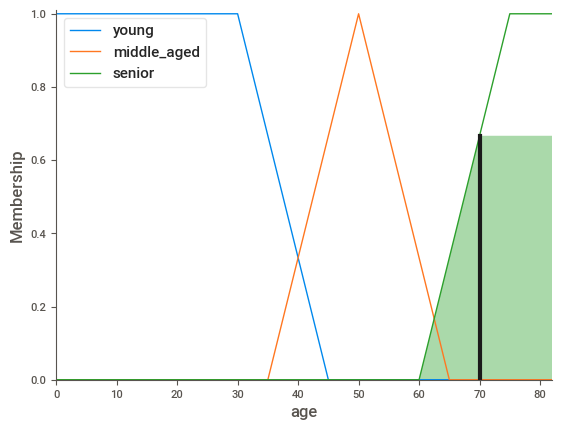

In [58]:
age.view(risk_sim) #70

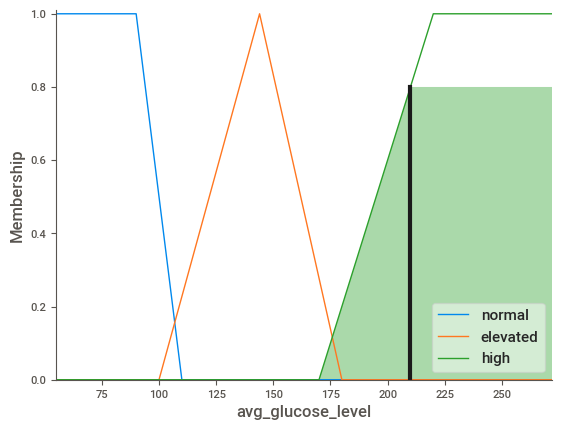

In [59]:
avg_glucose_level.view(risk_sim) #210

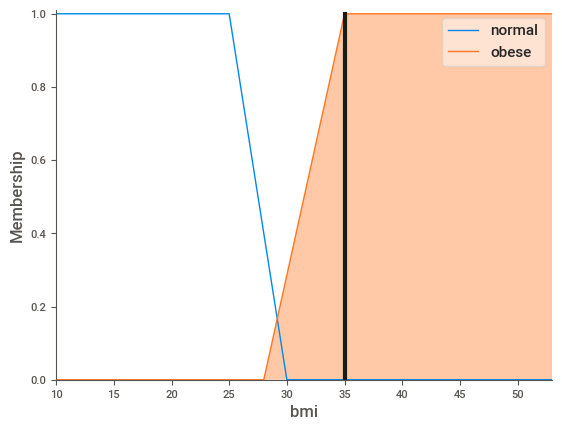

In [60]:
bmi.view(risk_sim) #35

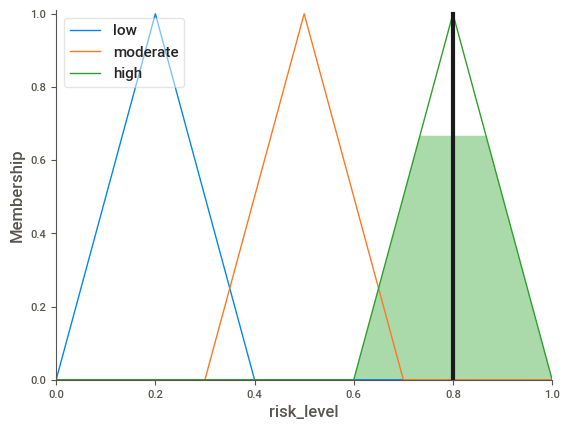

In [61]:
risk_level.view(risk_sim) #0.8%

In [62]:
# Input values (Example: young/middle age patient with normal/elevate glucose)
risk_sim.input['age'] = 40
risk_sim.input['avg_glucose_level'] = 105
risk_sim.input['bmi'] = 30

In [63]:
# Compute
risk_sim.compute()

In [64]:
risk_score_val=risk_sim.output['risk_level']
print(f"Risk Score : {round(risk_score_val, 1)} %")

Risk Score : 0.6 %


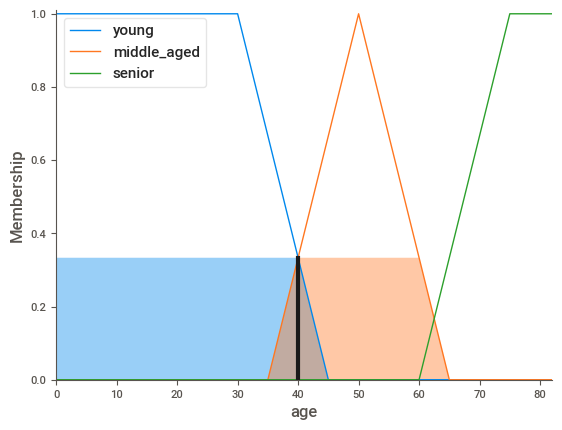

In [65]:
age.view(risk_sim) #40

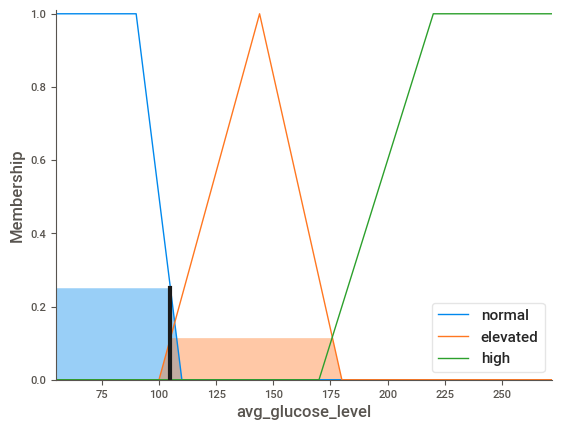

In [66]:
avg_glucose_level.view(risk_sim) #105

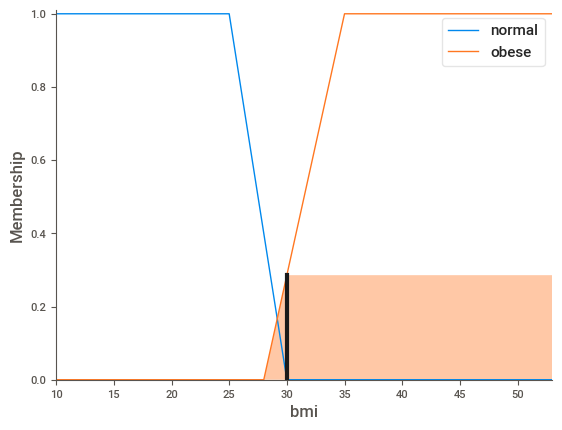

In [67]:
bmi.view(risk_sim) #30


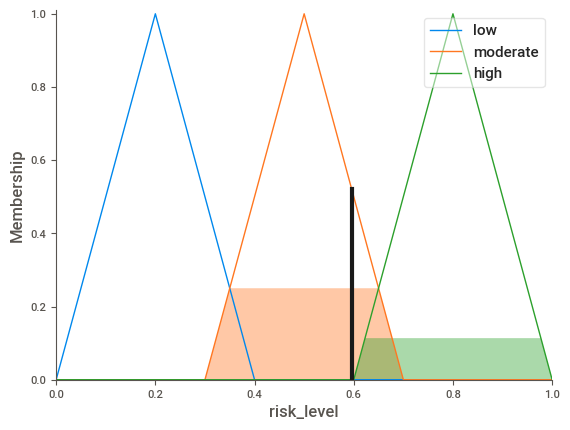

In [68]:
risk_level.view(risk_sim) #0.6%

## Genetic_Algorithm:

In this task, we applied a Genetic Algorithm (GA) to solve a feature selection problem.  
The goal is to automatically select the most important affective features from the dataset while removing redundant or less informative ones.
 

Instead of testing all possible combinations (which is very expensive), we use GA as an optimization technique to efficiently search for the best subset.



In [69]:
import random

In [70]:
# we Get the third copy of data which is called X_scaled and 
# convert the dataFrame into array so the GA can deal with 

X = X_scaled.values  

feature_names = [
    'gender','age','hypertension','heart_disease','ever_married',
    'work_type','Residence_type','avg_glucose_level','bmi','smoking_status'
]

n_features = len(feature_names)

In [ ]:
population_size = 10
generations = 10
mutation_probability = 0.1
 

print("The Genetic_Algorithm_parameters\n")
print("Population:", population_size)
print("Mutation probability:", mutation_probability)
print("Generations:", generations, "\n")
 

The Genetic_Algorithm_parameters

Population: 10
Mutation probability: 0.1
Generations: 10 



## Chromosome Representation(individual)

In this task:

- Each **chromosome** represents a possible solution (a subset of features).
- Each chromosome is a binary vector of length equal to the number of features.
 

Where:
- 1 → Feature is selected
- 0 → Feature is not selected

Each position in the chromosome is called a **gene**, representing a single feature.
 

In [72]:
def create_individual():
    individual = [random.randint(0,1) for _ in range(n_features)]
 
 # if the sum of the genes at the individual < 2 convert the zero
 # into one at two genes and then return the individual
 
    if sum(individual) < 2:
        individual[random.randint(0,n_features-1)] = 1
        individual[random.randint(0,n_features-1)] = 1
    
    return individual

### Fitness Function

The fitness function is used to evaluate how good each selected set of features is. We designed it based on three main ideas:

* **Variance**: to make sure the selected features contain useful information (higher variance = more informative).
* **Correlation penalty**: to avoid selecting features that are very similar to each other (reduce redundancy).
* **Size penalty**: to prevent choosing too many features and keep the model simple.

The final equation is:

Fitness = Variance − Correlation − Penalty

This helps us balance between:

* selecting informative features
* avoiding repeated information
* keeping the number of features small
 

### Why we used this method

We chose this method because it is simple and fast. Genetic algorithms need to evaluate many solutions in every generation, so using a complex method like clustering and calculating cluster quality each time would take a lot of time.

Instead, this approach uses basic calculations like variance and correlation, which are much faster. This makes the algorithm more efficient while still giving good results.

 


In [73]:
def fitness(individual):
    
    selected = [i for i in range(n_features) if individual[i] == 1]
 
    if len(selected) < 3:
        return 0

    X_sel = X[:, selected]
 
    variance_score = np.mean(np.var(X_sel, axis=0))
 
    corr = np.corrcoef(X_sel.T)
    correlation_penalty = np.mean(np.abs(corr - np.eye(len(selected))))
 
    size_penalty = 0.001 * len(selected)

    return variance_score - correlation_penalty - size_penalty

## Selection Method (Tournament Selection)

We used **Tournament Selection** to choose parents.

Steps:
1. Randomly select 3 individuals from the population
2. Choose the one with the highest fitness

This method is:
- Simple
- Efficient
- Helps maintain strong solutions while keeping diversity

In [74]:
def select_Parent(population):
    tournament_size=3
    tournament=random.sample(population ,tournament_size)
    best = tournament[0]
    best_fitness = fitness(best)

# here we compare the best with the three randomly chosen paerents
    for individual in tournament:
        if fitness(individual)>best_fitness:
         best=individual
         best_fitness=fitness(individual)

    return best    

## Crossover  

Crossover is used to generate new solutions (children) from two parents.

We used two methods:

1. **Single-Point Crossover**
   - Split parents at one point and combine them

2. **Two-Point Crossover**
   - Swap a segment between two points

This increases diversity and allows combining good features from different solutions.

In [75]:
def crossOver(p1,p2):
    method=random.choice(["single","two_point"])

    if method == "single":
        point= random.randint(1,n_features-1)
        child= p1[:point]+p2[point:]

    else:
     a = random.randint(1, n_features-2)
     b = random.randint(a+1, n_features-1)
     child = p1[:a] + p2[a:b] + p1[b:] 

    return child     

## Mutation

Mutation introduces random changes to a chromosome.

- Each gene has a small probability of flipping (0 → 1 or 1 → 0)

Purpose:
- Prevents the algorithm from getting stuck in local optima
- Maintains diversity in the population
 

In [76]:
def mutate(individual):
    
    for i in range(n_features):
        if random.random() < mutation_probability:
            individual[i] = 1 - individual[i]
    
    if sum(individual) < 2:
        individual[random.randint(0,n_features-1)] = 1
        individual[random.randint(0,n_features-1)] = 1
    
    return individual    

## Fitness Evolution

During the execution, we tracked the best fitness value in each generation.

Observation:
- The fitness value improves gradually over generations
- The algorithm converges toward better feature subsets

This shows that GA is effectively optimizing the solution.



In [77]:
def genetic_algorithm():
    
    population = [create_individual() for _ in range(population_size)]
    
    fitness_history = []
    
    for generation in range(generations):
        
        population = sorted(population, key=fitness, reverse=True)
        
        best = population[0]
        best_score = fitness(best)
        
        fitness_history.append(best_score)
        
        selected_features = [
            feature_names[i] for i in range(n_features) if best[i] == 1
        ]
        
        print(f"Generation {generation+1}")
        print(f"Selected Features: {selected_features}")
        print(f"Best Fitness: {best_score:.4f}")
        print("------")
        
        # Elitism
        #Elitism ensures that the best solution from the 
        #current generation is preserved in the next generation
        
        new_population = [best]
        
        while len(new_population) < population_size:
            
            parent1 = select_Parent(population)
            parent2 = select_Parent(population)
            
            child = crossOver(parent1, parent2)
            child = mutate(child)
            
            new_population.append(child)
        
        population = new_population
    
    # FINAL RESULT
    best = max(population, key=fitness)
    
    selected_features = [
        feature_names[i] for i in range(n_features) if best[i] == 1
    ]
    
    best_score = fitness(best)
    
    print("\n================ FINAL RESULT ================")
    print("Best Features:", selected_features)
    print("Best Fitness:", best_score)
    
    return {
        "best_features": selected_features,
        "best_score": best_score,
        "history": fitness_history
    }

## Comparison Between Baseline (Initial Population) and Final GA Solution

The Genetic Algorithm was evaluated by comparing the initial random population (baseline) with the final optimized solution obtained after multiple generations.

###  Baseline (Initial Population)

At the beginning of the algorithm, the population consisted of randomly generated feature subsets. These solutions were not optimized and included a relatively large number of features such as:

['gender', 'age', 'hypertension', 'work_type', 'Residence_type', 'avg_glucose_level', 'smoking_status']

The fitness score at this stage was relatively low (around 0.43), indicating weak feature quality, high redundancy, and the inclusion of less informative attributes.

---

###  Final GA Solution

After several generations of evolution, the Genetic Algorithm progressively improved the quality of the solutions by selecting, combining, and mutating better feature subsets.

The final optimal solution consisted of only three features:

['age', 'Residence_type', 'avg_glucose_level']

This reduced subset achieved a significantly higher fitness score of approximately 0.8274.

---

###  Key Improvements Observed

- Reduction in number of features: from 7 → 3
- Increase in fitness score: 0.43 → 0.82
- Removal of redundant and less informative features
- More compact and meaningful representation of the data

---

###  Conclusion

This comparison clearly demonstrates the effectiveness of the Genetic Algorithm. Starting from a random and unoptimized baseline, the algorithm successfully evolved towards a more efficient feature subset that provides higher quality representation of the dataset with fewer features. This highlights the ability of GA to perform intelligent feature selection and improve data quality significantly.

In [78]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
genetic_algorithm()

Generation 1
Selected Features: ['age', 'heart_disease', 'Residence_type', 'avg_glucose_level', 'smoking_status']
Best Fitness: 0.4964
------
Generation 2
Selected Features: ['gender', 'age', 'hypertension', 'Residence_type', 'avg_glucose_level']
Best Fitness: 0.5410
------
Generation 3
Selected Features: ['gender', 'age', 'hypertension', 'Residence_type', 'avg_glucose_level']
Best Fitness: 0.5410
------
Generation 4
Selected Features: ['age', 'heart_disease', 'Residence_type', 'avg_glucose_level']
Best Fitness: 0.6047
------
Generation 5
Selected Features: ['age', 'Residence_type', 'avg_glucose_level']
Best Fitness: 0.8274
------
Generation 6
Selected Features: ['age', 'Residence_type', 'avg_glucose_level']
Best Fitness: 0.8274
------
Generation 7
Selected Features: ['age', 'Residence_type', 'avg_glucose_level']
Best Fitness: 0.8274
------
Generation 8
Selected Features: ['age', 'Residence_type', 'avg_glucose_level']
Best Fitness: 0.8274
------
Generation 9
Selected Features: ['age', 

{'best_features': ['age', 'Residence_type', 'avg_glucose_level'],
 'best_score': np.float64(0.8274466709408862),
 'history': [np.float64(0.49642863512106894),
  np.float64(0.540969098586978),
  np.float64(0.540969098586978),
  np.float64(0.6046800069019387),
  np.float64(0.8274466709408862),
  np.float64(0.8274466709408862),
  np.float64(0.8274466709408862),
  np.float64(0.8274466709408862),
  np.float64(0.8274466709408862),
  np.float64(0.8274466709408862)]}

---
## Task 7: System Implementation

This section presents the **complete end-to-end pipeline** that integrates all components developed in this project:
1. **K-Medoids Clustering** – assigns a risk cluster to an incoming patient record.
2. **Fuzzy Logic Inference** – computes a continuous stroke-risk score using age, glucose, and BMI.
3. **Genetic Algorithm Feature Selection** – filters the record down to the GA-optimised features.

The function `stroke_risk_pipeline(record, kmedoids_model, scaler, risk_sim, ga_best_features)` accepts:
- `record` – a single patient dictionary with raw (unscaled) feature values
- `kmedoids_model` – the fitted `KMedoids` object
- `scaler` – the `StandardScaler` fitted on `['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease']`
- `risk_sim` – the `ControlSystemSimulation` object
- `ga_best_features` – the list of best features returned by the Genetic Algorithm

It returns a structured report dictionary and prints a human-readable summary.

In [79]:
CLUSTER_RISK_MAP = {
    0: 'Low Risk',
    1: 'Moderate Risk',
    2: 'High Risk'
}


def stroke_risk_pipeline(record: dict, kmedoids_model, scaler, risk_sim, ga_best_features: list) -> dict:

    cluster_raw = np.array([[
        record['age'],
        record['avg_glucose_level'],
        record['bmi'],
        record['hypertension'],
        record['heart_disease']
    ]])
    cluster_scaled = scaler.transform(cluster_raw)
    cluster_id = int(kmedoids_model.predict(cluster_scaled)[0])
    cluster_risk_label = CLUSTER_RISK_MAP.get(cluster_id, f'Cluster {cluster_id}')

    age_val     = float(record['age'])
    glucose_val = float(record['avg_glucose_level'])
    bmi_val     = float(record['bmi'])

    age_val     = np.clip(age_val,     0,   82)
    glucose_val = np.clip(glucose_val, 55, 272)
    bmi_val     = np.clip(bmi_val,     10,  53)

    risk_sim.input['age']               = age_val
    risk_sim.input['avg_glucose_level'] = glucose_val
    risk_sim.input['bmi']               = bmi_val
    risk_sim.compute()

    fuzzy_score = round(float(risk_sim.output['risk_level']), 4)

    if fuzzy_score < 0.4:
        fuzzy_label = 'Low'
    elif fuzzy_score < 0.65:
        fuzzy_label = 'Moderate'
    else:
        fuzzy_label = 'High'

    ga_values = {feat: record.get(feat, None) for feat in ga_best_features}

    action_map = {
        ('Low Risk',      'Low'):      'Routine annual check-up; maintain healthy lifestyle.',
        ('Low Risk',      'Moderate'): 'Schedule a follow-up within 6 months; monitor glucose.',
        ('Low Risk',      'High'):     'Prompt medical evaluation recommended; review diet.',
        ('Moderate Risk', 'Low'):      'Bi-annual check-ups; lifestyle modifications advised.',
        ('Moderate Risk', 'Moderate'): 'Consult a physician; consider preventive medication.',
        ('Moderate Risk', 'High'):     'Urgent clinical review; stroke-prevention protocol.',
        ('High Risk',     'Low'):      'Regular monitoring; address hypertension / diabetes.',
        ('High Risk',     'Moderate'): 'Specialist referral recommended within 1 month.',
        ('High Risk',     'High'):     'IMMEDIATE medical attention – very high stroke risk!',
    }
    recommended_action = action_map.get(
        (cluster_risk_label, fuzzy_label),
        'Consult a healthcare provider for personalised guidance.'
    )

    result = {
        'cluster_id':         cluster_id,
        'cluster_risk_label': cluster_risk_label,
        'fuzzy_risk_score':   fuzzy_score,
        'fuzzy_risk_label':   fuzzy_label,
        'ga_features_used':   ga_best_features,
        'ga_feature_values':  ga_values,
        'recommended_action': recommended_action,
    }

    print('=' * 60)
    print('         STROKE RISK ASSESSMENT PIPELINE REPORT')
    print('=' * 60)
    print(f"  Patient Input")
    print(f"    Age               : {record['age']}")
    print(f"    Avg Glucose       : {record['avg_glucose_level']}")
    print(f"    BMI               : {record['bmi']}")
    print(f"    Hypertension      : {'Yes' if record['hypertension'] else 'No'}")
    print(f"    Heart Disease     : {'Yes' if record['heart_disease'] else 'No'}")
    print('-' * 60)
    print(f"  [Step 1] K-Medoids Cluster")
    print(f"    Cluster ID        : {cluster_id}")
    print(f"    Risk Profile      : {cluster_risk_label}")
    print('-' * 60)
    print(f"  [Step 2] Fuzzy Logic Inference")
    print(f"    Fuzzy Risk Score  : {fuzzy_score:.4f}  (0 = lowest, 1 = highest)")
    print(f"    Fuzzy Risk Label  : {fuzzy_label}")
    print('-' * 60)
    print(f"  [Step 3] GA-Selected Features")
    for feat, val in ga_values.items():
        print(f"    {feat:<25}: {val}")
    print('-' * 60)
    print(f"  [Step 4] Recommended Action")
    print(f"    >> {recommended_action}")
    print('=' * 60)

    return result

### Pipeline Flowchart

The diagram below illustrates the flow of data through the four steps of the pipeline.

```
┌─────────────────────────────────────────────────────┐
│              RAW PATIENT RECORD (dict)               │
│  age │ avg_glucose_level │ bmi │ hypertension │ ...  │
└──────────────────────┬──────────────────────────────┘
                       │
          ┌────────────▼──────────────┐
          │   STEP 1: K-Medoids        │
          │  Scale 5 features with     │
          │  StandardScaler, predict   │
          │  cluster (0 / 1 / 2)       │
          │  → cluster_risk_label      │
          └────────────┬──────────────┘
                       │
          ┌────────────▼──────────────┐
          │   STEP 2: Fuzzy Logic      │
          │  Inputs: age, glucose, bmi │
          │  9 IF-THEN rules           │
          │  Centroid defuzzification  │
          │  → fuzzy_risk_score [0,1]  │
          └────────────┬──────────────┘
                       │
          ┌────────────▼──────────────┐
          │   STEP 3: GA Features      │
          │  Extract values for the    │
          │  GA-optimised feature set  │
          │  → ga_feature_values       │
          └────────────┬──────────────┘
                       │
          ┌────────────▼──────────────┐
          │   STEP 4: Recommendation   │
          │  Map (cluster, fuzzy) pair │
          │  to clinical action string │
          └────────────┬──────────────┘
                       │
          ┌────────────▼──────────────┐
          │        FINAL REPORT        │
          │  Structured dict + printed │
          │  human-readable summary    │
          └───────────────────────────┘
```

### Demonstration – running the pipeline on two real samples from the dataset


In [80]:
ga_features = ['age', 'Residence_type', 'avg_glucose_level']

sample_high = {
    'age': 72,
    'avg_glucose_level': 215.0,
    'bmi': 36.5,
    'hypertension': 1,
    'heart_disease': 1,
    'gender': 1,
    'ever_married': 1,
    'Residence_type': 1,
    'work_type': 'Private',
    'smoking_status': 'formerly smoked'
}

result_high = stroke_risk_pipeline(
    record          = sample_high,
    kmedoids_model  = kmedoids,
    scaler          = scaler,
    risk_sim        = risk_sim,
    ga_best_features= ga_features
)

print()

sample_low = {
    'age': 28,
    'avg_glucose_level': 88.0,
    'bmi': 22.1,
    'hypertension': 0,
    'heart_disease': 0,
    'gender': 0,
    'ever_married': 0,
    'Residence_type': 0,
    'work_type': 'Private',
    'smoking_status': 'never smoked'
}

result_low = stroke_risk_pipeline(
    record          = sample_low,
    kmedoids_model  = kmedoids,
    scaler          = scaler,
    risk_sim        = risk_sim,
    ga_best_features= ga_features
)

         STROKE RISK ASSESSMENT PIPELINE REPORT
  Patient Input
    Age               : 72
    Avg Glucose       : 215.0
    BMI               : 36.5
    Hypertension      : Yes
    Heart Disease     : Yes
------------------------------------------------------------
  [Step 1] K-Medoids Cluster
    Cluster ID        : 2
    Risk Profile      : High Risk
------------------------------------------------------------
  [Step 2] Fuzzy Logic Inference
    Fuzzy Risk Score  : 0.8000  (0 = lowest, 1 = highest)
    Fuzzy Risk Label  : High
------------------------------------------------------------
  [Step 3] GA-Selected Features
    age                      : 72
    Residence_type           : 1
    avg_glucose_level        : 215.0
------------------------------------------------------------
  [Step 4] Recommended Action
    >> IMMEDIATE medical attention – very high stroke risk!

         STROKE RISK ASSESSMENT PIPELINE REPORT
  Patient Input
    Age               : 28
    Avg Glucose       :